<a href="https://colab.research.google.com/github/Sk-Kamrej/Bank_Marketing_Project/blob/main/Code/BMP_ADASYN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# =============================================================
#  BANK MARKETING PROJECT (Machine Learning)
# =============================================================

In [14]:
# ==============================
# 1. INSTALL DEPENDENCIES
# ==============================

!pip install -q lightgbm catboost imbalanced-learn xgboost scikit-learn pandas numpy scipy openpyxl

In [15]:
# ==============================
# 2. IMPORTS LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix)

from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import ADASYN

In [16]:
# ==============================
# 3. LOAD DATASET
# ==============================

df = pd.read_csv('/content/Bank_Marketing_Full.csv', sep=';')

In [17]:
# ==============================
# 4. PREPROCESSING
# ==============================

# Drop Leakage Feature
df = df.drop('duration', axis=1)

# Handle "unknown" Values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

# Encode Target
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

In [18]:
# ==============================
# 5. SPLIT DATA
# ==============================

# Split Features & Target
X = df.drop('y', axis=1)
y = df['y']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ADASYN Oversampling
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_scaled, y_train)

In [19]:
# ==============================
# 6. CROSS VALIDATION
# ==============================

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [42]:
# ==============================
# 7. CUSTOM UNIVERSAL FUNCTION
# ==============================
all_results = []

def evaluate_model(name, best_model):

    global all_results

    results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_ad, y_train_ad)):

        X_tr, X_val = X_train_ad[train_idx], X_train_ad[val_idx]
        y_tr, y_val = y_train_ad.iloc[train_idx], y_train_ad.iloc[val_idx]

        start = time.time()
        best_model.fit(X_tr, y_tr)
        training_time = time.time() - start

        y_pred = best_model.predict(X_val)
        y_prob = best_model.predict_proba(X_val)[:,1]

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()

        specificity = tn/(tn+fp)
        recall = tp/(tp+fn)

        results.append({
            "Fold": fold+1,
            "Classifier": name,
            "Accuracy": round(accuracy_score(y_val, y_pred), 4),
            "Precision": round(precision_score(y_val, y_pred, zero_division=0), 4),
            "Recall": round(recall, 4),
            "Specificity": round(specificity, 4),
            "F1 Score": round(f1_score(y_val, y_pred), 4),
            "ROC-AUC": round(roc_auc_score(y_val, y_prob), 4),
            "MCC": round(matthews_corrcoef(y_val, y_pred), 4),
            "G-Mean": round(np.sqrt(recall * specificity), 4),
            "Kappa": round(cohen_kappa_score(y_val, y_pred), 4),
            "Balanced Accuracy": round((recall + specificity)/2, 4),
            "Training Time (s)": round(training_time, 4)
        })

    df_results = pd.DataFrame(results)

    # STORE RESULTS
    all_results.append(df_results)

    print(f"\nResults for {name}:")
    display(df_results)

# MODEL: Logistic Regression

In [44]:
# ==============================
# MODEL: LogisticRegression
# ==============================
from sklearn.linear_model import LogisticRegression

# Base Model
model = LogisticRegression(max_iter=500)

# Parameter grid
params = {
    "C":[0.01, 0.1, 1, 10],
    "solver":["lbfgs","liblinear"]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=10, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("Logistic Regression", best_model)

Best parameters: {'solver': 'lbfgs', 'C': 1}
Best CV accuracy: 0.6893
Test accuracy: 0.787
Total Training Time: 1 min 23 sec

Results for Logistic Regression:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,Logistic Regression,0.6971,0.7514,0.5882,0.8057,0.6599,0.7547,0.4037,0.6884,0.3940,0.6970,1.2336
1,2,Logistic Regression,0.6916,0.7380,0.5934,0.7897,0.6578,0.7487,0.3907,0.6845,0.3831,0.6915,1.7008
2,3,Logistic Regression,0.6862,0.7311,0.5881,0.7842,0.6519,0.7442,0.3797,0.6791,0.3723,0.6861,1.3902
3,4,Logistic Regression,0.6921,0.7421,0.5877,0.7962,0.6560,0.7512,0.3926,0.6841,0.3840,0.6920,0.9944
4,5,Logistic Regression,0.6840,0.7339,0.5764,0.7914,0.6457,0.7422,0.3766,0.6754,0.3679,0.6839,0.9825
5,6,Logistic Regression,0.6871,0.7370,0.5809,0.7931,0.6497,0.7470,0.3827,0.6787,0.3741,0.6870,1.1057
6,7,Logistic Regression,0.6975,0.7550,0.5840,0.8109,0.6586,0.7532,0.4055,0.6881,0.3949,0.6974,0.9178
7,8,Logistic Regression,0.6789,0.7265,0.5727,0.7849,0.6405,0.7365,0.3659,0.6704,0.3576,0.6788,1.2328
8,9,Logistic Regression,0.6936,0.7479,0.5834,0.8036,0.6555,0.7449,0.3968,0.6847,0.3871,0.6935,0.9081
9,10,Logistic Regression,0.6847,0.7388,0.5707,0.7985,0.6440,0.7429,0.3792,0.6751,0.3693,0.6846,1.0366


# MODEL: Decision Tree

In [46]:
# ==============================
# MODEL: Decision Tree
# ==============================
from sklearn.tree import DecisionTreeClassifier

# Base Model
model = DecisionTreeClassifier()

# Parameter grid
params = {
    "max_depth":[5,10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=10, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("Decision Tree", best_model)

Best parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best CV accuracy: 0.9115
Test accuracy: 0.8659
Total Training Time: 0 min 59 sec

Results for Decision Tree:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,Decision Tree,0.9113,0.9339,0.8852,0.9374,0.9089,0.9333,0.8238,0.9110,0.8227,0.9113,0.7431
1,2,Decision Tree,0.9093,0.9292,0.8859,0.9326,0.9071,0.9264,0.8195,0.9090,0.8186,0.9093,0.5860
2,3,Decision Tree,0.9118,0.9265,0.8944,0.9292,0.9102,0.9294,0.8242,0.9117,0.8237,0.9118,0.5576
3,4,Decision Tree,0.9130,0.9279,0.8955,0.9306,0.9114,0.9326,0.8266,0.9129,0.8261,0.9130,0.5678
4,5,Decision Tree,0.9115,0.9274,0.8927,0.9302,0.9097,0.9289,0.8236,0.9113,0.8230,0.9115,0.5664
5,6,Decision Tree,0.9161,0.9320,0.8975,0.9347,0.9145,0.9337,0.8328,0.9159,0.8322,0.9161,0.5464
6,7,Decision Tree,0.9168,0.9349,0.8958,0.9378,0.9149,0.9348,0.8343,0.9165,0.8336,0.9168,0.5607
7,8,Decision Tree,0.9011,0.9251,0.8725,0.9295,0.8981,0.9239,0.8034,0.9006,0.8021,0.9010,0.5466
8,9,Decision Tree,0.9113,0.9277,0.8921,0.9306,0.9095,0.9327,0.8233,0.9111,0.8227,0.9113,0.5639
9,10,Decision Tree,0.9139,0.9278,0.8976,0.9302,0.9124,0.9336,0.8282,0.9137,0.8278,0.9139,0.5384


# MODEL: Random Forest

In [48]:
# ==============================
# MODEL: Random Forest
# ==============================
from sklearn.ensemble import RandomForestClassifier

# Base Model
model = RandomForestClassifier()

# Parameter grid
params = {
    "n_estimators":[200,300],
    "max_depth":[10,20]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=10, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("Random Forest", best_model)

Best parameters: {'n_estimators': 300, 'max_depth': 20}
Best CV accuracy: 0.9376
Test accuracy: 0.8903
Total Training Time: 11 min 4 sec

Results for Random Forest:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,Random Forest,0.9382,0.9488,0.9263,0.9501,0.9374,0.9807,0.8767,0.9381,0.8764,0.9382,26.5690
1,2,Random Forest,0.9396,0.9499,0.9281,0.9511,0.9388,0.9805,0.8794,0.9395,0.8792,0.9396,26.0568
2,3,Random Forest,0.9355,0.9410,0.9291,0.9419,0.9350,0.9810,0.8710,0.9354,0.8709,0.9355,26.4105
3,4,Random Forest,0.9380,0.9481,0.9267,0.9494,0.9373,0.9783,0.8763,0.9380,0.8761,0.9380,26.3410
4,5,Random Forest,0.9363,0.9423,0.9294,0.9432,0.9358,0.9800,0.8727,0.9363,0.8726,0.9363,26.3556
5,6,Random Forest,0.9392,0.9508,0.9263,0.9521,0.9384,0.9823,0.8788,0.9391,0.8785,0.9392,25.4940
6,7,Random Forest,0.9392,0.9539,0.9229,0.9555,0.9382,0.9831,0.8789,0.9391,0.8785,0.9392,25.6777
7,8,Random Forest,0.9298,0.9351,0.9236,0.9360,0.9293,0.9777,0.8597,0.9298,0.8596,0.9298,25.7014
8,9,Random Forest,0.9375,0.9481,0.9257,0.9494,0.9367,0.9807,0.8753,0.9374,0.8750,0.9375,25.5830
9,10,Random Forest,0.9394,0.9461,0.9318,0.9470,0.9389,0.9816,0.8789,0.9394,0.8788,0.9394,26.3606


# MODEL: Gradient Boosting

In [50]:
# ==============================
# MODEL: Gradient Boosting
# ==============================
from sklearn.ensemble import GradientBoostingClassifier

# Base Model
model = GradientBoostingClassifier()

# Parameter grid
params = {
    "n_estimators":[100,150],
    "learning_rate":[0.05,1]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=5, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("Gradient Boosting", best_model)

Best parameters: {'n_estimators': 150, 'learning_rate': 1}
Best CV accuracy: 0.9366
Test accuracy: 0.8995
Total Training Time: 19 min 44 sec

Results for Gradient Boosting:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,Gradient Boosting,0.9338,0.9658,0.8993,0.9682,0.9313,0.9717,0.8696,0.9331,0.8675,0.9337,39.9632
1,2,Gradient Boosting,0.9372,0.9726,0.8996,0.9747,0.9347,0.9695,0.8768,0.9364,0.8744,0.9372,39.5741
2,3,Gradient Boosting,0.9370,0.9650,0.9068,0.9672,0.9350,0.9698,0.8756,0.9365,0.8740,0.9370,37.7948
3,4,Gradient Boosting,0.9336,0.9658,0.8989,0.9682,0.9311,0.9672,0.8692,0.9329,0.8672,0.9335,38.1659
4,5,Gradient Boosting,0.9370,0.9633,0.9085,0.9655,0.9351,0.9732,0.8754,0.9365,0.8740,0.9370,37.4981
5,6,Gradient Boosting,0.9384,0.9706,0.9040,0.9726,0.9361,0.9742,0.8788,0.9377,0.8767,0.9383,37.0802
6,7,Gradient Boosting,0.9384,0.9637,0.9109,0.9658,0.9366,0.9727,0.8781,0.9379,0.8767,0.9383,39.8369
7,8,Gradient Boosting,0.9308,0.9594,0.8996,0.9620,0.9285,0.9679,0.8634,0.9303,0.8617,0.9308,37.0362
8,9,Gradient Boosting,0.9384,0.9685,0.9061,0.9706,0.9363,0.9697,0.8786,0.9378,0.8767,0.9384,36.7798
9,10,Gradient Boosting,0.9404,0.9680,0.9109,0.9699,0.9386,0.9759,0.8824,0.9399,0.8809,0.9404,36.8765


# MODEL: XGBoost

In [52]:
# ==============================
# MODEL: XGBoost
# ==============================
from xgboost import XGBClassifier

# Base Model
model = XGBClassifier(eval_metric='logloss')

# Parameter grid
params = {
    "n_estimators":[300,500],
    "learning_rate":[0.03,0.05],
    "max_depth":[3,5]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("XGBoost", best_model)

Best parameters: {'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05}
Best CV accuracy: 0.9341
Test accuracy: 0.9023
Total Training Time: 6 min 2 sec

Results for XGBoost:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,XGBoost,0.9310,0.9736,0.8859,0.9761,0.9277,0.9732,0.8656,0.9299,0.8620,0.9310,8.9488
1,2,XGBoost,0.9339,0.9717,0.8938,0.9740,0.9311,0.9718,0.8707,0.9330,0.8679,0.9339,6.5103
2,3,XGBoost,0.9329,0.9661,0.8972,0.9685,0.9303,0.9725,0.8680,0.9322,0.8658,0.9329,9.2565
3,4,XGBoost,0.9319,0.9709,0.8903,0.9733,0.9289,0.9701,0.8667,0.9309,0.8637,0.9318,7.4483
4,5,XGBoost,0.9336,0.9651,0.8996,0.9675,0.9312,0.9734,0.8692,0.9329,0.8672,0.9335,7.7120
5,6,XGBoost,0.9367,0.9736,0.8975,0.9757,0.9340,0.9754,0.8760,0.9358,0.8733,0.9366,8.8582
6,7,XGBoost,0.9351,0.9728,0.8951,0.9750,0.9324,0.9771,0.8730,0.9342,0.8702,0.9351,6.6596
7,8,XGBoost,0.9308,0.9683,0.8907,0.9709,0.9279,0.9704,0.8645,0.9299,0.8617,0.9308,9.0924
8,9,XGBoost,0.9374,0.9776,0.8952,0.9795,0.9345,0.9744,0.8778,0.9364,0.8747,0.9373,6.8145
9,10,XGBoost,0.9374,0.9698,0.9027,0.9719,0.9351,0.9748,0.8768,0.9367,0.8747,0.9373,8.2753


# MODEL: LightGBM

In [54]:
# ==============================
# MODEL: LightGBM
# ==============================
from lightgbm import LGBMClassifier

# Base Model
model = LGBMClassifier(verbosity=-1)

# Parameter grid
params = {
    "n_estimators":[300,500],
    "learning_rate":[0.03,0.05]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("LightGBM", best_model)

Best parameters: {'n_estimators': 500, 'learning_rate': 0.05}
Best CV accuracy: 0.9391
Test accuracy: 0.9013
Total Training Time: 3 min 12 sec

Results for LightGBM:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,LightGBM,0.9379,0.9783,0.8955,0.9802,0.9351,0.9758,0.8789,0.9369,0.8757,0.9378,6.1560
1,2,LightGBM,0.9382,0.9741,0.9003,0.9761,0.9357,0.9739,0.8789,0.9374,0.8764,0.9382,5.1413
2,3,LightGBM,0.9384,0.9671,0.9075,0.9692,0.9364,0.9740,0.8784,0.9378,0.8767,0.9383,6.2193
3,4,LightGBM,0.9389,0.9737,0.9020,0.9757,0.9365,0.9722,0.8802,0.9381,0.8778,0.9389,5.1811
4,5,LightGBM,0.9389,0.9685,0.9071,0.9706,0.9368,0.9757,0.8795,0.9383,0.8778,0.9389,5.8948
5,6,LightGBM,0.9411,0.9767,0.9037,0.9785,0.9388,0.9767,0.8847,0.9403,0.8822,0.9411,5.3973
6,7,LightGBM,0.9411,0.9728,0.9075,0.9747,0.9390,0.9783,0.8842,0.9405,0.8822,0.9411,5.4740
7,8,LightGBM,0.9334,0.9678,0.8965,0.9702,0.9308,0.9723,0.8692,0.9326,0.8668,0.9334,10.3144
8,9,LightGBM,0.9415,0.9785,0.9027,0.9802,0.9391,0.9760,0.8856,0.9406,0.8829,0.9414,6.4393
9,10,LightGBM,0.9415,0.9711,0.9099,0.9730,0.9395,0.9768,0.8847,0.9409,0.8829,0.9414,5.2342


# MODEL: CatBoost

In [56]:
# ==============================
# MODEL: CatBoost
# ==============================
from catboost import CatBoostClassifier

# Base Model
model = CatBoostClassifier(verbose=0)

# Parameter grid
params = {
    "iterations":[200,300],
    "depth":[4,6]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("CatBoost", best_model)

Best parameters: {'iterations': 300, 'depth': 6}
Best CV accuracy: 0.9382
Test accuracy: 0.9001
Total Training Time: 5 min 16 sec

Results for CatBoost:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,CatBoost,0.9334,0.9727,0.8917,0.9750,0.9305,0.9747,0.8699,0.9325,0.8668,0.9334,8.3223
1,2,CatBoost,0.9377,0.9740,0.8993,0.9761,0.9352,0.9732,0.8780,0.9369,0.8754,0.9377,9.9679
2,3,CatBoost,0.9382,0.9702,0.9040,0.9723,0.9360,0.9730,0.8784,0.9376,0.8764,0.9382,10.1561
3,4,CatBoost,0.9353,0.9721,0.8962,0.9744,0.9326,0.9714,0.8732,0.9344,0.8706,0.9353,9.8381
4,5,CatBoost,0.9385,0.9668,0.9082,0.9689,0.9366,0.9745,0.8787,0.9380,0.8771,0.9385,8.3377
5,6,CatBoost,0.9413,0.9760,0.9047,0.9778,0.9390,0.9759,0.8849,0.9405,0.8826,0.9412,10.2595
6,7,CatBoost,0.9401,0.9738,0.9044,0.9757,0.9378,0.9773,0.8824,0.9394,0.8802,0.9401,10.1386
7,8,CatBoost,0.9329,0.9661,0.8972,0.9685,0.9303,0.9716,0.8680,0.9322,0.8658,0.9329,9.2932
8,9,CatBoost,0.9397,0.9763,0.9013,0.9781,0.9373,0.9738,0.8821,0.9389,0.8795,0.9397,9.2743
9,10,CatBoost,0.9447,0.9734,0.9144,0.9750,0.9429,0.9763,0.8911,0.9442,0.8894,0.9447,10.4716


# MODEL: SVM

In [58]:
# ==============================
# MODEL: SVM
# ==============================
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Base Model
base_svm = LinearSVC(max_iter=2000)

# Wrap with calibration to get probabilities
model = CalibratedClassifierCV(base_svm)

# Parameter grid
params = {
    "estimator__C": [0.1, 0.5, 1]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("SVM", best_model)

Best parameters: {'estimator__C': 0.5}
Best CV accuracy: 0.688
Test accuracy: 0.7808
Total Training Time: 2 min 57 sec

Results for SVM:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,SVM,0.6964,0.7454,0.5958,0.7969,0.6622,0.7537,0.4008,0.6890,0.3927,0.6963,7.0928
1,2,SVM,0.6930,0.7362,0.6005,0.7852,0.6615,0.7483,0.3926,0.6867,0.3858,0.6929,6.5240
2,3,SVM,0.6828,0.7218,0.5939,0.7715,0.6516,0.7440,0.3714,0.6769,0.3655,0.6827,7.0005
3,4,SVM,0.6902,0.7359,0.5922,0.7880,0.6563,0.7500,0.3877,0.6831,0.3802,0.6901,6.2517
4,5,SVM,0.6825,0.7270,0.5833,0.7815,0.6473,0.7414,0.3721,0.6751,0.3648,0.6824,6.6202
5,6,SVM,0.6869,0.7324,0.5881,0.7856,0.6523,0.7463,0.3812,0.6797,0.3737,0.6868,6.8043
6,7,SVM,0.6958,0.7471,0.5912,0.8003,0.6600,0.7539,0.4003,0.6878,0.3915,0.6957,6.7416
7,8,SVM,0.6763,0.7186,0.5785,0.7739,0.6410,0.7364,0.3594,0.6691,0.3525,0.6762,6.8344
8,9,SVM,0.6919,0.7404,0.5903,0.7934,0.6569,0.7444,0.3918,0.6843,0.3837,0.6918,6.7710
9,10,SVM,0.6840,0.7334,0.5776,0.7903,0.6462,0.7427,0.3765,0.6756,0.3679,0.6839,6.6403


# MODEL: KNN

In [60]:
# ==============================
# MODEL: KNN
# ==============================
from sklearn.neighbors import KNeighborsClassifier

# Base Model
model = KNeighborsClassifier()

# Parameter grid
params = {
    "n_neighbors":[5,7,9],
    "weights":["uniform","distance"]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("KNN", best_model)

Best parameters: {'weights': 'distance', 'n_neighbors': 5}
Best CV accuracy: 0.8874
Test accuracy: 0.7813
Total Training Time: 2 min 33 sec

Results for KNN:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,KNN,0.8877,0.8345,0.9671,0.8085,0.8959,0.9439,0.7855,0.8842,0.7755,0.8878,0.0041
1,2,KNN,0.8937,0.8403,0.9719,0.8157,0.9014,0.9472,0.7973,0.8904,0.7875,0.8938,0.0049
2,3,KNN,0.8841,0.8273,0.9705,0.7979,0.8932,0.9414,0.7800,0.8800,0.7683,0.8842,0.0058
3,4,KNN,0.8898,0.8321,0.9764,0.8034,0.8985,0.9433,0.7915,0.8856,0.7796,0.8899,0.0046
4,5,KNN,0.8845,0.8261,0.9736,0.7955,0.8938,0.9415,0.7815,0.8801,0.7690,0.8845,0.0043
5,6,KNN,0.8845,0.8294,0.9678,0.8013,0.8932,0.9435,0.7799,0.8806,0.7690,0.8845,0.0044
6,7,KNN,0.8889,0.8361,0.9671,0.8109,0.8969,0.9417,0.7875,0.8855,0.7779,0.8890,0.0042
7,8,KNN,0.8814,0.8265,0.9650,0.7979,0.8904,0.9334,0.7737,0.8775,0.7628,0.8815,0.0043
8,9,KNN,0.8872,0.8293,0.9750,0.7995,0.8962,0.9389,0.7866,0.8829,0.7744,0.8873,0.0041
9,10,KNN,0.8918,0.8368,0.9733,0.8105,0.8999,0.9428,0.7943,0.8882,0.7837,0.8919,0.0041


# MODEL: MLP

In [62]:
# ==============================
# MODEL: MLP
# ==============================
from sklearn.neural_network import MLPClassifier

# Base Model
model = MLPClassifier(max_iter=100, early_stopping=True)

# Parameter grid
params = {
    "hidden_layer_sizes":[(50,), (100,)],
    "alpha":[0.0001,0.001]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("MLP", best_model)

Best parameters: {'hidden_layer_sizes': (100,), 'alpha': 0.0001}
Best CV accuracy: 0.8658
Test accuracy: 0.8172
Total Training Time: 10 min 19 sec

Results for MLP:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,MLP,0.8686,0.8630,0.8760,0.8611,0.8694,0.9396,0.7372,0.8685,0.7371,0.8686,26.1524
1,2,MLP,0.8650,0.8596,0.8722,0.8577,0.8658,0.9369,0.7300,0.8649,0.7299,0.8650,32.4081
2,3,MLP,0.8685,0.8727,0.8626,0.8745,0.8676,0.9411,0.7371,0.8685,0.7371,0.8685,42.9650
3,4,MLP,0.8649,0.8644,0.8653,0.8646,0.8649,0.9384,0.7299,0.8649,0.7299,0.8649,28.5690
4,5,MLP,0.8670,0.8660,0.8681,0.8659,0.8670,0.9404,0.7340,0.8670,0.7340,0.8670,34.9849
5,6,MLP,0.8667,0.8610,0.8742,0.8591,0.8675,0.9393,0.7334,0.8666,0.7333,0.8667,31.0408
6,7,MLP,0.8598,0.8744,0.8400,0.8796,0.8568,0.9333,0.7202,0.8596,0.7196,0.8598,25.2251
7,8,MLP,0.8639,0.8484,0.8859,0.8420,0.8667,0.9323,0.7286,0.8637,0.7278,0.8639,37.7681
8,9,MLP,0.8793,0.8740,0.8863,0.8724,0.8801,0.9459,0.7587,0.8793,0.7586,0.8793,41.7330
9,10,MLP,0.8723,0.8717,0.8729,0.8717,0.8723,0.9400,0.7446,0.8723,0.7446,0.8723,27.9650


# MODEL: Bagging

In [64]:
# ==============================
# MODEL: Bagging
# ==============================
from sklearn.ensemble import BaggingClassifier

# Base Model
model = BaggingClassifier()

# Parameter grid
params = {
    "n_estimators":[50,100]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=20, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("Bagging", best_model)

Best parameters: {'n_estimators': 50}
Best CV accuracy: 0.9353
Test accuracy: 0.8849
Total Training Time: 9 min 35 sec

Results for Bagging:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,Bagging,0.9341,0.9499,0.9164,0.9518,0.9329,0.9747,0.8688,0.9339,0.8682,0.9341,21.9845
1,2,Bagging,0.9333,0.9508,0.9137,0.9528,0.9319,0.9733,0.8672,0.9330,0.8665,0.9332,23.1128
2,3,Bagging,0.9356,0.9447,0.9253,0.9460,0.9349,0.9749,0.8715,0.9356,0.8713,0.9356,20.8148
3,4,Bagging,0.9334,0.9505,0.9143,0.9525,0.9321,0.9722,0.8674,0.9332,0.8668,0.9334,21.5180
4,5,Bagging,0.9343,0.9471,0.9198,0.9487,0.9332,0.9753,0.8689,0.9341,0.8685,0.9343,20.5109
5,6,Bagging,0.9396,0.9549,0.9225,0.9566,0.9385,0.9754,0.8797,0.9394,0.8791,0.9396,21.3033
6,7,Bagging,0.9365,0.9514,0.9198,0.9531,0.9354,0.9754,0.8735,0.9363,0.8730,0.9365,21.8976
7,8,Bagging,0.9271,0.9456,0.9061,0.9480,0.9254,0.9710,0.8549,0.9268,0.8542,0.9271,20.6611
8,9,Bagging,0.9350,0.9494,0.9188,0.9511,0.9338,0.9765,0.8704,0.9348,0.8699,0.9349,22.9295
9,10,Bagging,0.9370,0.9490,0.9236,0.9504,0.9361,0.9771,0.8743,0.9369,0.8740,0.9370,24.3508


# MODEL: Stacking

In [66]:
# ==============================
# MODEL: Stacking
# ==============================
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Base Models
model = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=100)),
        ('dt', DecisionTreeClassifier(max_depth=10)),
        ('xgb', XGBClassifier(n_estimators=200, eval_metric='logloss')),
        ('lgbm', LGBMClassifier(n_estimators=200)),
    ],

    # Meta-Model
    final_estimator=LogisticRegression(max_iter=500),
    n_jobs=-1
)

# Parameter grid
params = {
    "final_estimator__C": [0.1, 1]
}

# Randomized Search
search = RandomizedSearchCV(model, params, n_iter=2, cv=skf, scoring="accuracy", n_jobs=-1)

# Train
start_total = time.time()

search.fit(X_train_ad, y_train_ad)

total_training_time = time.time() - start_total

best_model = search.best_estimator_

# Output
print("Best parameters:", search.best_params_)
print("Best CV accuracy:", round(search.best_score_,4))

# Test accuracy
y_pred = best_model.predict(X_test_scaled)
print("Test accuracy:", round(accuracy_score(y_test, y_pred),4))

# Training time
mins = int(total_training_time // 60)
secs = int(total_training_time % 60)

print(f"Total Training Time: {mins} min {secs} sec")

# Fold-wise evaluation
evaluate_model("Stacking", best_model)

Best parameters: {'final_estimator__C': 0.1}
Best CV accuracy: 0.9412
Test accuracy: 0.8863
Total Training Time: 27 min 29 sec

Results for Stacking:


,Fold,Classifier,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC,MCC,G-Mean,Kappa,Balanced Accuracy,Training Time (s)
0,1,Stacking,0.9415,0.9439,0.9387,0.9443,0.9413,0.9842,0.8829,0.9415,0.8829,0.9415,81.8669
1,2,Stacking,0.9437,0.9490,0.9376,0.9497,0.9433,0.9841,0.8874,0.9437,0.8874,0.9437,78.2507
2,3,Stacking,0.9406,0.9392,0.9421,0.9391,0.9406,0.9848,0.8812,0.9406,0.8812,0.9406,75.9865
3,4,Stacking,0.9391,0.9426,0.9349,0.9432,0.9387,0.9822,0.8782,0.9390,0.8781,0.9391,77.2810
4,5,Stacking,0.9397,0.9391,0.9404,0.9391,0.9397,0.9838,0.8795,0.9397,0.8795,0.9397,76.8142
5,6,Stacking,0.9454,0.9486,0.9417,0.9490,0.9451,0.9849,0.8908,0.9454,0.8908,0.9454,80.9687
6,7,Stacking,0.9439,0.9456,0.9417,0.9460,0.9437,0.9861,0.8877,0.9439,0.8877,0.9439,80.7900
7,8,Stacking,0.9322,0.9321,0.9321,0.9323,0.9321,0.9815,0.8644,0.9322,0.8644,0.9322,87.0336
8,9,Stacking,0.9415,0.9439,0.9387,0.9442,0.9413,0.9845,0.8829,0.9415,0.8829,0.9415,77.2290
9,10,Stacking,0.9423,0.9403,0.9445,0.9401,0.9424,0.9858,0.8846,0.9423,0.8846,0.9423,77.5306


# WILCOXON SIGNED-RANK TEST

In [76]:
# ==============================
# WILCOXON SIGNED-RANK TEST
# ==============================

import pandas as pd
from scipy.stats import wilcoxon

# Combine all fold results
final_results = pd.concat(all_results, ignore_index=True)

models = final_results["Classifier"].unique()

# Create empty matrix
wilcoxon_matrix = pd.DataFrame(index=models, columns=models)

# Pairwise comparison
metric = "Accuracy"

for i in range(len(models)):
    for j in range(len(models)):

        if i == j:
            wilcoxon_matrix.iloc[i, j] = "-"
        else:
            m1 = final_results[final_results["Classifier"] == models[i]][metric]
            m2 = final_results[final_results["Classifier"] == models[j]][metric]

            try:
                stat, p = wilcoxon(m1, m2)
                wilcoxon_matrix.iloc[i, j] = round(p, 4)
            except:
                wilcoxon_matrix.iloc[i, j] = "NA"

print("\n===== WILCOXON TEST (p-values) =====\n")
display(wilcoxon_matrix)

# Save
wilcoxon_matrix.to_excel("ADASYN_Wilcoxon_Test.xlsx")

# Download
from google.colab import files
files.download("ADASYN_Wilcoxon_Test.xlsx")


===== WILCOXON TEST (p-values) =====



,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting,XGBoost,LightGBM,CatBoost,SVM,KNN,MLP,Bagging,Stacking
Logistic Regression,-,0.002,0.002,0.002,0.002,0.002,0.002,0.0137,0.002,0.002,0.002,0.002
Decision Tree,0.002,-,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002
Random Forest,0.002,0.002,-,0.6758,0.0059,0.0117,0.3105,0.002,0.002,0.002,0.0098,0.002
Gradient Boosting,0.002,0.002,0.6758,-,0.0039,0.002,0.0039,0.002,0.002,0.002,0.0195,0.002
XGBoost,0.002,0.002,0.0059,0.0039,-,0.002,0.002,0.002,0.002,0.002,0.4316,0.002
LightGBM,0.002,0.002,0.0117,0.002,0.002,-,0.0684,0.002,0.002,0.002,0.002,0.0273
CatBoost,0.002,0.002,0.3105,0.0039,0.002,0.0684,-,0.002,0.002,0.002,0.0039,0.0215
SVM,0.0137,0.002,0.002,0.002,0.002,0.002,0.002,-,0.002,0.002,0.002,0.002
KNN,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,-,0.002,0.002,0.002
MLP,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,-,0.002,0.002


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# TOPSIS RANKING

In [77]:
# ==============================
# TOPSIS RANKING
# ==============================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Combine results
final_results = pd.concat(all_results, ignore_index=True)

# Mean performance
mean_results = final_results.groupby("Classifier").mean(numeric_only=True).reset_index()

# Metrics
metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "MCC", "G-Mean"]

# Step 1: Decision matrix
decision_matrix = mean_results[metrics].values

# Step 2: Normalize
scaler = MinMaxScaler()
norm_matrix = scaler.fit_transform(decision_matrix)

# Step 3: Equal weights
weights = np.ones(len(metrics)) / len(metrics)

# Step 4: Weighted matrix
weighted_matrix = norm_matrix * weights

# Step 5: Ideal best & worst
ideal_best = np.max(weighted_matrix, axis=0)
ideal_worst = np.min(weighted_matrix, axis=0)

# Step 6: Distances
dist_best = np.sqrt(((weighted_matrix - ideal_best) ** 2).sum(axis=1))
dist_worst = np.sqrt(((weighted_matrix - ideal_worst) ** 2).sum(axis=1))

# Step 7: TOPSIS score
topsis_score = dist_worst / (dist_best + dist_worst)

# Add results
mean_results["TOPSIS Score"] = topsis_score
mean_results["TOPSIS Rank"] = mean_results["TOPSIS Score"].rank(ascending=False)

# Sort
topsis_result = mean_results.sort_values(by="TOPSIS Score", ascending=False)

print("\n===== TOPSIS RANKING =====\n")
display(topsis_result[["Classifier", "TOPSIS Score", "TOPSIS Rank"]])

# Save
topsis_result.to_excel("ADASYN_TOPSIS_Ranking.xlsx", index=False)

# Download
from google.colab import files
files.download("ADASYN_TOPSIS_Ranking.xlsx")


===== TOPSIS RANKING =====



,Classifier,TOPSIS Score,TOPSIS Rank
10,Stacking,0.944508,1.0
8,Random Forest,0.940181,2.0
5,LightGBM,0.934589,3.0
0,Bagging,0.933071,4.0
1,CatBoost,0.932815,5.0
3,Gradient Boosting,0.931661,6.0
11,XGBoost,0.923252,7.0
2,Decision Tree,0.842159,8.0
4,KNN,0.742268,9.0
7,MLP,0.706385,10.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# CORRELATION MATRIX

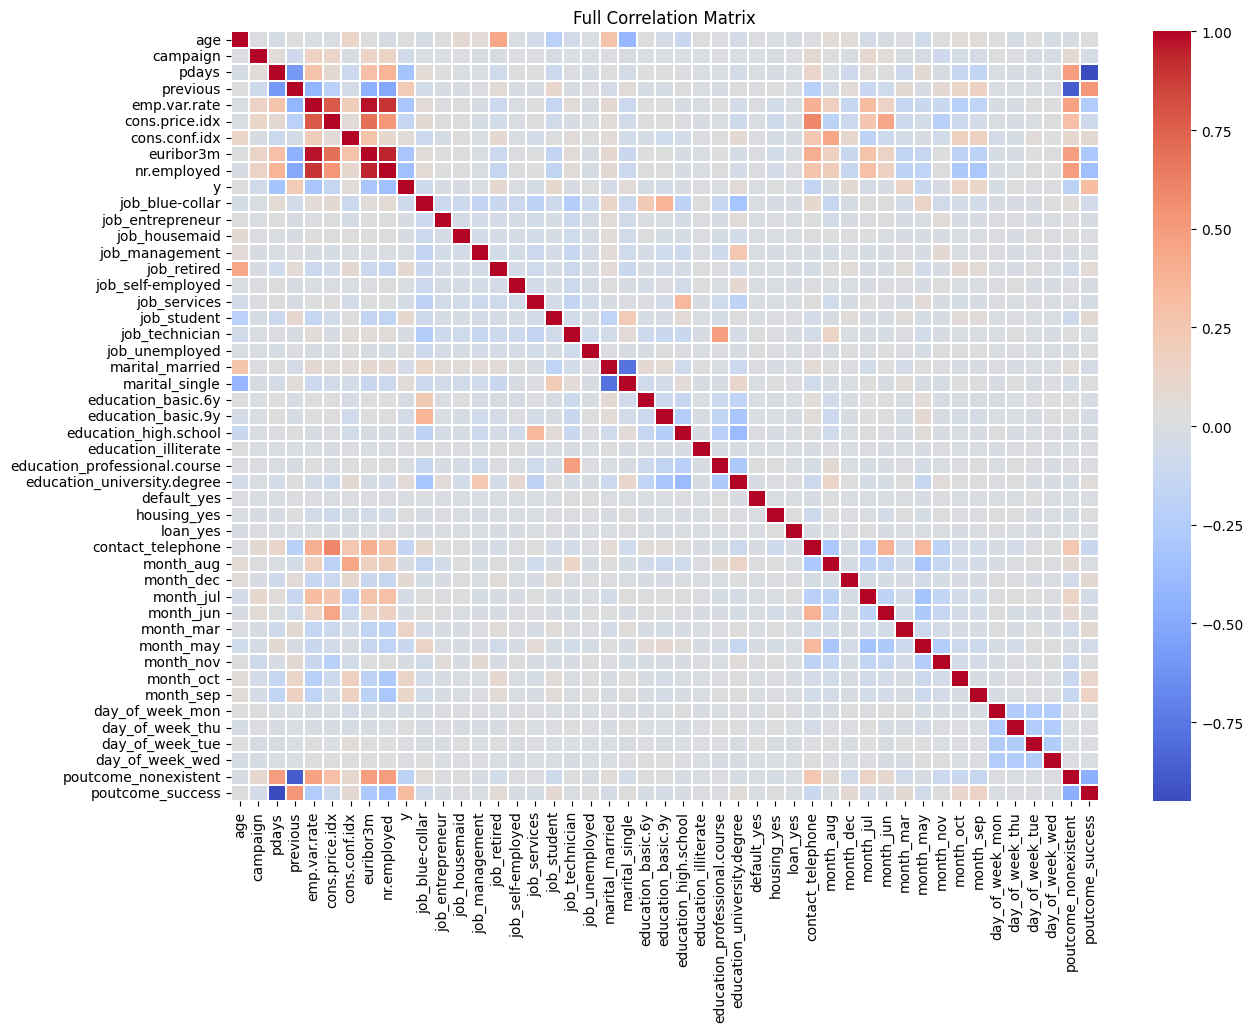


Top Positive Correlations: 
y                              1.000000
poutcome_success               0.316269
previous                       0.230181
month_mar                      0.144014
month_oct                      0.137366
month_sep                      0.126067
job_student                    0.093955
job_retired                    0.092221
month_dec                      0.079303
education_university.degree    0.057689
Name: y, dtype: float64

Top Negative Correlations: 
campaign               -0.066357
job_blue-collar        -0.074423
month_may              -0.108271
cons.price.idx         -0.136211
contact_telephone      -0.144773
poutcome_nonexistent   -0.193507
emp.var.rate           -0.298334
euribor3m              -0.307771
pdays                  -0.324914
nr.employed            -0.354678
Name: y, dtype: float64


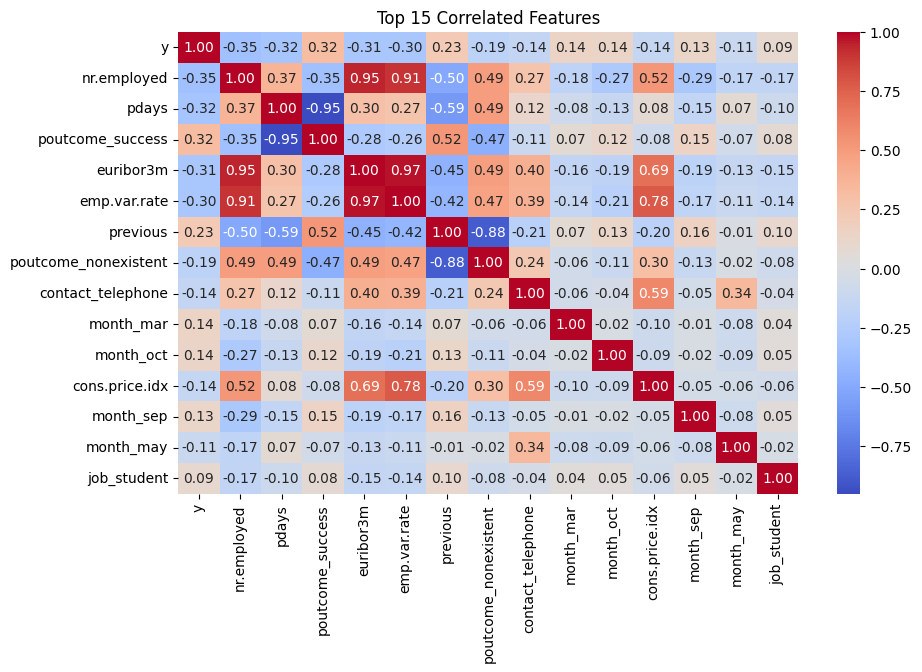

In [ ]:
# =============================================================
# CORRELATION MATRIX (FOR BANK MARKETING PROJECT)
# =============================================================
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# -------------------------------
# 1. FULL CORRELATION MATRIX
# -------------------------------
corr_matrix = df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidths=0.3)

plt.title("Full Correlation Matrix")
plt.show()


# -------------------------------
# 2. CORRELATION WITH TARGET (y)
# -------------------------------
corr_target = corr_matrix["y"].sort_values(ascending=False)

print("\nTop Positive Correlations: ")
print(corr_target.head(10))

print("\nTop Negative Correlations: ")
print(corr_target.tail(10))


# -------------------------------
# 3. TOP FEATURES HEATMAP (BEST)
# -------------------------------
top_features = corr_target.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10,6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Top 15 Correlated Features")
plt.show()


# -------------------------------
# 4. SAVE TO EXCEL
# -------------------------------
corr_matrix.to_excel("Correlation_Matrix.xlsx")

In [75]:
# ==============================
# SELECT BEST 4 MODELS
# ==============================

import pandas as pd

# Combine all fold results
final_results = pd.concat(all_results, ignore_index=True)

# Mean performance of each model
mean_results = final_results.groupby("Classifier").mean(numeric_only=True).reset_index()

# Metrics to consider (best for imbalanced data)
metrics = ["ROC-AUC", "F1 Score", "MCC", "G-Mean"]

# Ranking (higher is better)
for m in metrics:
    mean_results[m + "_rank"] = mean_results[m].rank(ascending=False)

# Final rank (average of all metric ranks)
mean_results["Final Rank"] = mean_results[[m + "_rank" for m in metrics]].mean(axis=1)

# Sort and get top 4 models
top4 = mean_results.sort_values(by="Final Rank").head(4)

# Display results
print("\n===== TOP 4 BEST MODELS =====")
display(top4[["Classifier", "Final Rank"] + metrics])

# Store names for later use (SHAP, LIME etc.)
best_models = top4["Classifier"].tolist()

print("\nBest 4 Models:", best_models)


===== TOP 4 BEST MODELS =====


,Classifier,Final Rank,ROC-AUC,F1 Score,MCC,G-Mean
10,Stacking,1.00,0.98419,0.94082,0.88196,0.94098
5,LightGBM,2.25,0.97517,0.93677,0.88043,0.93834
8,Random Forest,3.50,0.98059,0.93658,0.87477,0.93721
1,CatBoost,3.75,0.97417,0.93582,0.87867,0.93746



Best 4 Models: ['Stacking', 'LightGBM', 'Random Forest', 'CatBoost']
